# Power Device Loss Comparison — Si vs SiC vs GaN

First-pass trade study of **switch losses across device technologies**, decoupled from any
specific controller or topology. Each device is a `PowerDevice` object holding datasheet
parameters; every loss term is a method evaluated at an `OperatingPoint`.

**Loss model (per switch):** conduction · turn-on · turn-off · Coss (incl. ZVS hysteresis) ·
gate drive · reverse recovery (Qrr) · deadtime reverse-conduction.

**Sources**
- Graovac, Pürschel & Kiep, *MOSFET Power Losses Calculation Using the Data-Sheet Parameters*, Infineon App Note (2006) — Si / general method.
- Li, Evans & Johnson, *SiC/GaN power semiconductor devices: a theoretical comparison…*, IET EST 8(1) (2018) — SiC / GaN.

> ⚠️ Device parameters below are **representative 650 V-class values** chosen to exercise the
> structure. Replace with real datasheet numbers before drawing any conclusion.


In [8]:
from dataclasses import dataclass, replace
import numpy as np
import matplotlib.pyplot as plt


@dataclass
class OperatingPoint:
    """Where the device is being operated (generic, not tied to a topology)."""
    vbus: float = 400.0    # V  - voltage the switch blocks / commutates
    irms: float = 3.0      # A  - rms channel current (conduction)
    i_sw: float = 5.0      # A  - current at the switching instant (turn-off / turn-on)
    fsw: float = 500e3     # Hz - switching frequency
    tdead: float = 50e-9   # s  - deadtime (reverse-conduction window)
    tj: float = 100.0      # C  - junction temperature
    zvs: bool = True       # soft-switched (e.g. LLC) vs hard-switched


@dataclass
class PowerDevice:
    name: str
    tech: str              # 'Si' | 'SiC' | 'GaN'
    color: str
    vds_max: float         # V   - blocking-voltage rating
    rds_on_25: float       # ohm - on-resistance at Tj = 25 C
    rds_ratio_125: float   # Rds(125C)/Rds(25C), rough thermal derating
    qg: float              # C   - total gate charge at vdrive
    vdrive: float          # V   - gate-drive voltage swing
    eoss_400: float        # J   - Coss stored energy at 400 V
    coss_hyst: float       # -   - fraction of Eoss dissipated per cycle under ZVS
    eon_ref: float         # J   - turn-on energy at (vref, iref), hard switching
    eoff_ref: float        # J   - turn-off energy at (vref, iref)
    qrr: float             # C   - reverse-recovery charge (0 for GaN)
    vsd: float             # V   - 3rd-quadrant / body-diode drop during deadtime
    rds_dyn: float = 1.0   # -   - dynamic Rds(on) multiplier (GaN current collapse)
    vref: float = 400.0    # V   - reference for switching-energy scaling
    iref: float = 10.0     # A   - reference for switching-energy scaling

    # --- helpers ---
    def rds_on(self, tj):
        k = (tj - 25.0) / (125.0 - 25.0)                 # linear temp interpolation
        return self.rds_on_25 * (1 + k * (self.rds_ratio_125 - 1)) * self.rds_dyn

    # --- loss terms (all return watts) ---
    def p_conduction(self, op):
        return op.irms**2 * self.rds_on(op.tj)

    def p_turn_on(self, op):
        if op.zvs:                                        # ZVS removes turn-on loss
            return 0.0
        e = self.eon_ref * (op.vbus / self.vref) * (op.i_sw / self.iref)
        return e * op.fsw

    def p_turn_off(self, op):
        e = self.eoff_ref * (op.vbus / self.vref) * (op.i_sw / self.iref)
        return e * op.fsw

    def p_coss(self, op):
        e = self.eoss_400 * (op.vbus / 400.0)             # rough linear V-scaling
        return e * (self.coss_hyst if op.zvs else 1.0) * op.fsw

    def p_gate(self, op):
        return self.qg * self.vdrive * op.fsw

    def p_qrr(self, op):
        if op.zvs:                                        # soft commutation avoids recovery
            return 0.0
        return self.qrr * op.vbus * op.fsw

    def p_deadtime(self, op):
        if not op.zvs:                                    # only matters under ZVS
            return 0.0
        return self.vsd * op.i_sw * op.tdead * op.fsw

    def losses(self, op):
        return {
            'conduction': self.p_conduction(op),
            'turn-on':    self.p_turn_on(op),
            'turn-off':   self.p_turn_off(op),
            'Coss':       self.p_coss(op),
            'gate':       self.p_gate(op),
            'Qrr':        self.p_qrr(op),
            'deadtime':   self.p_deadtime(op),
        }

    def total_loss(self, op):
        return sum(self.losses(op).values())


In [9]:
# Representative 650 V-class parts (illustrative datasheet-style numbers).
# Edit these freely -- the structure is what matters for the first pass.

si = PowerDevice(
    name='Si SJ (650V)',  tech='Si',  color='#4E79A7', vds_max=650,
    rds_on_25=0.065, rds_ratio_125=2.3,          # superjunction ~doubles hot
    qg=50e-9,  vdrive=11,
    eoss_400=6.0e-6, coss_hyst=0.05,             # large, nonlinear Coss
    eon_ref=40e-6, eoff_ref=20e-6,
    qrr=200e-9, vsd=0.9,
)

sic = PowerDevice(
    name='SiC (650V)',    tech='SiC', color='#F28E2B', vds_max=650,
    rds_on_25=0.060, rds_ratio_125=1.4,
    qg=30e-9,  vdrive=18,                         # -4/+15-ish swing
    eoss_400=4.0e-6, coss_hyst=0.10,             # notable soft-switching Coss loss
    eon_ref=20e-6, eoff_ref=10e-6,
    qrr=80e-9,  vsd=3.5,                          # high body-diode drop
)

gan = PowerDevice(
    name='GaN (650V)',    tech='GaN', color='#59A14F', vds_max=650,
    rds_on_25=0.050, rds_ratio_125=1.6,
    qg=5.5e-9, vdrive=6,
    eoss_400=2.0e-6, coss_hyst=0.03,             # low Coss
    eon_ref=10e-6, eoff_ref=5e-6,
    qrr=0.0,   vsd=3.0,                           # no body diode; channel reverse-conduction
    rds_dyn=1.2,                                  # dynamic Rds(on) / current-collapse derating
)

devices = [si, sic, gan]
for d in devices:
    print(f'{d.name:14s}  Rds(100C)={d.rds_on(100)*1e3:5.1f} mOhm')


Si SJ (650V)    Rds(100C)=128.4 mOhm
SiC (650V)      Rds(100C)= 78.0 mOhm
GaN (650V)      Rds(100C)= 87.0 mOhm


In [10]:
# Nominal operating point for the breakdown plot (generic, ZVS/soft-switched).
op = OperatingPoint(vbus=400, irms=3.0, i_sw=5.0, fsw=500e3, tdead=50e-9, tj=100, zvs=True)

print(f'{"device":14s} {"total [W]":>10s}')
for d in devices:
    print(f'{d.name:14s} {d.total_loss(op):10.2f}')


device          total [W]
Si SJ (650V)         6.69
SiC (650V)           4.11
GaN (650V)           2.45


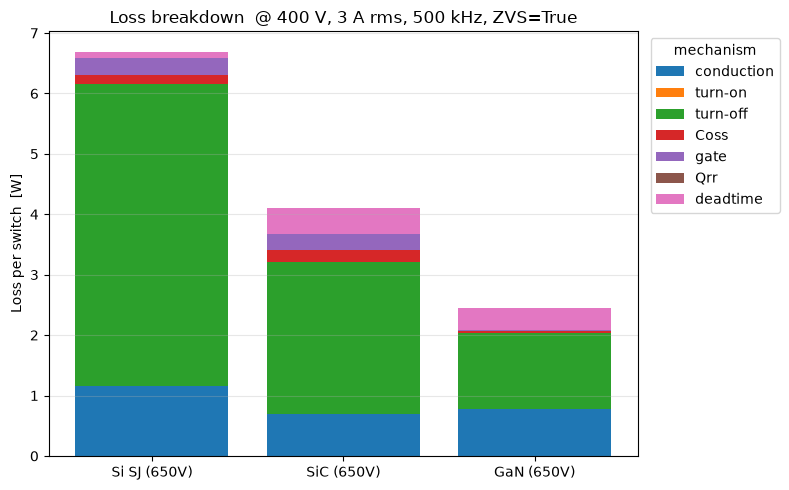

In [11]:
# --- Plot 1: stacked loss breakdown per device (soft-switched) ---
cats = list(devices[0].losses(op).keys())
x = np.arange(len(devices))
bottom = np.zeros(len(devices))

plt.figure(figsize=(8, 5))
for cat in cats:
    vals = np.array([d.losses(op)[cat] for d in devices])
    plt.bar(x, vals, bottom=bottom, label=cat)
    bottom += vals

plt.xticks(x, [d.name for d in devices])
plt.ylabel('Loss per switch  [W]')
plt.title(f'Loss breakdown  @ {op.vbus:.0f} V, {op.irms:.0f} A rms, '
          f'{op.fsw/1e3:.0f} kHz, ZVS={op.zvs}')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='mechanism')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


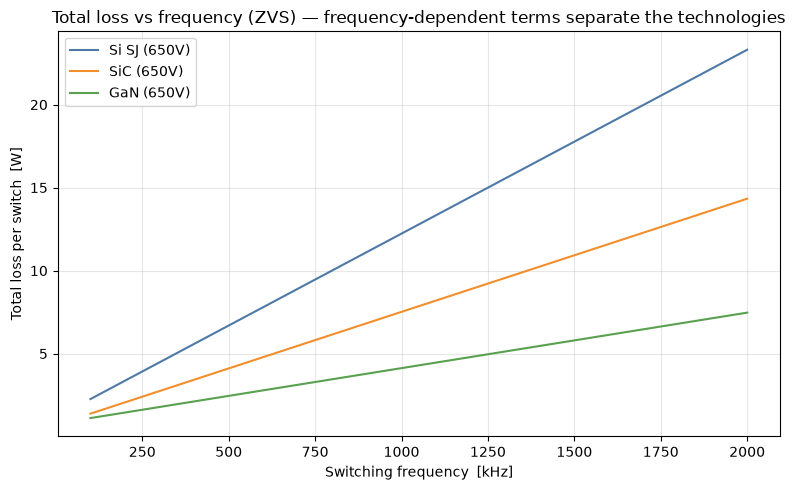

In [12]:
# --- Plot 2: total loss vs switching frequency (soft-switched) ---
freqs = np.linspace(100e3, 2e6, 200)

plt.figure(figsize=(8, 5))
for d in devices:
    tot = [d.total_loss(replace(op, fsw=f)) for f in freqs]
    plt.plot(freqs/1e3, tot, label=d.name, color=d.color)

plt.xlabel('Switching frequency  [kHz]')
plt.ylabel('Total loss per switch  [W]')
plt.title('Total loss vs frequency (ZVS) — frequency-dependent terms separate the technologies')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


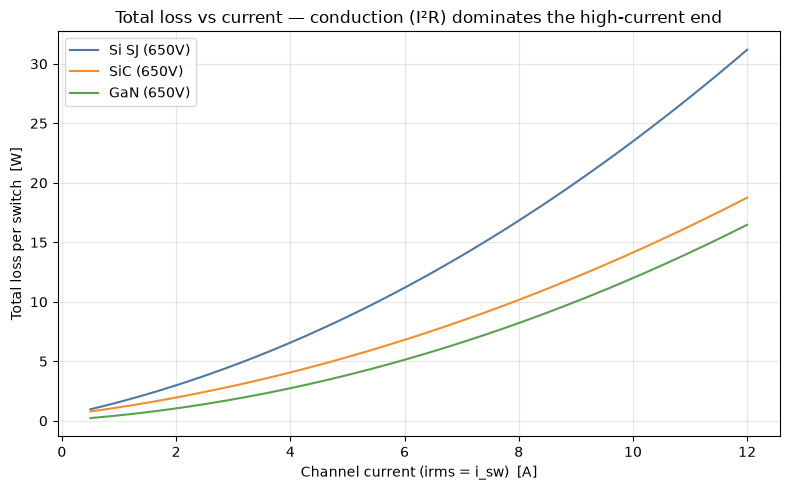

In [13]:
# --- Plot 3: total loss vs load current (soft-switched) ---
currents = np.linspace(0.5, 12, 200)

plt.figure(figsize=(8, 5))
for d in devices:
    tot = [d.total_loss(replace(op, irms=I, i_sw=I)) for I in currents]
    plt.plot(currents, tot, label=d.name, color=d.color)

plt.xlabel('Channel current (irms = i_sw)  [A]')
plt.ylabel('Total loss per switch  [W]')
plt.title('Total loss vs current — conduction (I²R) dominates the high-current end')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


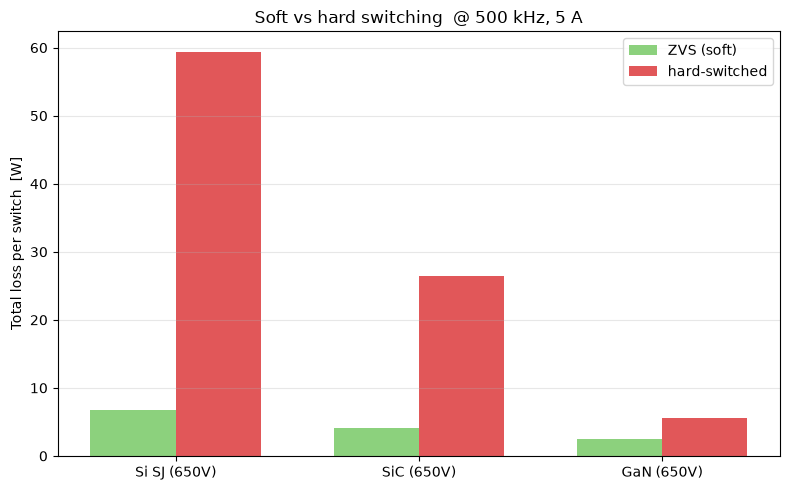

In [14]:
# --- Plot 4: ZVS vs hard-switched total loss (the technology gap widens hard-switched) ---
x = np.arange(len(devices))
w = 0.35
zvs_tot  = [d.total_loss(replace(op, zvs=True))  for d in devices]
hard_tot = [d.total_loss(replace(op, zvs=False)) for d in devices]

plt.figure(figsize=(8, 5))
plt.bar(x - w/2, zvs_tot,  w, label='ZVS (soft)',   color='#8CD17D')
plt.bar(x + w/2, hard_tot, w, label='hard-switched', color='#E15759')
plt.xticks(x, [d.name for d in devices])
plt.ylabel('Total loss per switch  [W]')
plt.title(f'Soft vs hard switching  @ {op.fsw/1e3:.0f} kHz, {op.i_sw:.0f} A')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Notes & next steps

- **Turn-on** and **Qrr** are zeroed under `zvs=True` (ZVS removes both) — that's why Plot 4
  shows the technologies bunching up under soft switching and spreading apart hard-switched.
- **Switching-energy scaling** (`eon_ref`, `eoff_ref`) is a simple linear `V·I` scaling from a
  reference point — fine for a first pass; swap for datasheet `Eon/Eoff` curves later.
- **Coss hysteresis** (`coss_hyst`) and **dynamic Rds(on)** (`rds_dyn`, GaN) are the two
  device-specific effects flagged in the trade study — both are single editable fields here.
- To specialise to the LLC: set `irms`, `i_sw` (≈ magnetizing peak), `fsw`, and `vbus` from the
  resonant-tank study and keep `zvs=True`.
